# Chapter 10: Inference on Spheres

Source span: printed pages 193-244; PDF pages 209-259. The source was inspected for orientation only: section order, terminology, and the kinds of statistics used. This notebook uses original prose, synthetic data, generated diagrams, and executable checks.

## Chapter Goal

This chapter turns a cloud of unit vectors on `S^2` into inferential statements that still make sense after the coordinate frame is rotated. The central objects are the mean resultant vector, the Fisher concentration equation, confidence cones for a mean direction, uniformity tests, and axial scatter diagnostics for Watson and Bingham alternatives.

The practical question is: **which visible feature of the sphere is a statistic allowed to measure?** A mean resultant detects one-sided clustering. A scatter spectrum detects axes, girdles, and non-rotational axial structure. A cap probability says how much model mass lies inside a cone. A Sobolev or transformed-resultant test asks the same uniformity question after embedding the sphere into a richer function space.

All examples below use small synthetic data sets. They are not replacements for the book's data tables; they are controlled scenes where the geometry and the validation checks can be inspected directly.

## Computational Translation Guide

| Source concept | Computational object | Invariance or check |
| --- | --- | --- |
| Spherical observation | a row of a numeric array with Euclidean norm one | unit norms stay one after simulation and rotation |
| Fisher/von Mises-Fisher model on `S^2` | density proportional to `exp(kappa * mu dot x)` with `||mu||=1` | the MLE solves `A_3(kappa_hat) = Rbar` |
| Mean-direction confidence region | a spherical cap/cone centered on `mu_hat` | cap threshold lies in `[-1, 1]`; true pole is inside in the reference simulation |
| Uniformity against mean-shift alternatives | Rayleigh statistic `3 n Rbar^2` | null simulation tracks a `chi^2_3` reference; clustered data moves right |
| Axial alternatives | scatter matrix `T = n^{-1} sum x_i x_i^T` | `T` is unchanged by arbitrary sign flips of the axes |
| Watson versus Bingham structure | eigenvalue pattern of `T` | bipolar Watson: one large eigenvalue; girdle Watson: one small eigenvalue; Bingham: separated eigenvalues |
| General uniformity framework | transformed resultants or Fourier/Sobolev coefficients | a test should remain rotation invariant, not coordinate-label dependent |

## Visualization Storyboard And Library Routing

- **Spherical EDA and confidence cone.** Matplotlib gives a durable two-panel artifact: a 3D sphere with the fitted cone and a Lambert equal-area view centered at the sample mean. The learner checks unit points, cap shape, and whether the true pole is inside the cone.
- **Fisher concentration and cap probability.** SciPy root finding solves the MLE equation, while Matplotlib exposes the likelihood profile and cap mass curve. The learner checks how `Rbar`, `kappa_hat`, and the semi-angle move together.
- **Uniformity reference behavior.** NumPy simulation plus SciPy chi-square references show what Rayleigh and Bingham statistics see. The learner compares mean-shift and axial alternatives rather than treating uniformity as one test.
- **Axial Watson/Bingham diagnostics.** Eigenvalue bars and sign-flip residuals make axial data visible without choosing arbitrary signs. The learner checks the scatter spectrum rather than a misleading mean direction.
- **Interactive spherical dashboard.** Plotly is used for the rotatable sphere because the cap, mean vector, and axial structure are inherently 3D.

Artifacts are saved under `artifacts/chapter-10` with concept names, and the final cells assert both artifact integrity and chapter-specific numerical identities.

In [1]:
from pathlib import Path
import sys


def find_book_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (
            (candidate / "AGENTS.md").exists()
            and (candidate / "scripts" / "validate_dirstats_course.py").exists()
            and (candidate / "utils").exists()
        ):
            return candidate
    raise RuntimeError("Could not locate Directional-Statistics course root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-10"
ARTIFACT_BASE = BOOK_ROOT / "artifacts" / TOPIC
source_span = {"printed": "193-244", "pdf": "209-259"}

print(f"Course root: {BOOK_ROOT}")
print(f"Artifact base: {ARTIFACT_BASE.relative_to(BOOK_ROOT)}")

Course root: D:\Geometry\Directional-Statistics
Artifact base: artifacts\chapter-10


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from scipy import optimize, stats

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.validation import assert_artifacts

np.set_printoptions(precision=5, suppress=True)
rng = np.random.default_rng(10010)


def normalize(vector, axis=None, eps=1e-15):
    array = np.asarray(vector, dtype=float)
    norm = np.linalg.norm(array, axis=axis, keepdims=True)
    if np.any(norm < eps):
        raise ValueError("cannot normalize a near-zero vector")
    return array / norm


def unit_rows(points):
    return normalize(points, axis=1)


def tangent_basis(axis):
    axis = normalize(axis)
    trial = np.array([1.0, 0.0, 0.0])
    if abs(float(np.dot(axis, trial))) > 0.86:
        trial = np.array([0.0, 1.0, 0.0])
    e1 = normalize(np.cross(axis, trial))
    e2 = normalize(np.cross(axis, e1))
    return e1, e2


def random_unit_sphere(n, rng):
    return unit_rows(rng.normal(size=(n, 3)))


def sample_vmf(mu, kappa, n, rng):
    '''Sample from the 3D Fisher/vMF model by drawing cos(theta) exactly.'''
    mu = normalize(mu)
    if kappa < 1e-10:
        return random_unit_sphere(n, rng)
    u = rng.random(n)
    exp_neg_2k = math.exp(-2.0 * float(kappa))
    cos_theta = 1.0 + np.log(u + (1.0 - u) * exp_neg_2k) / float(kappa)
    sin_theta = np.sqrt(np.maximum(0.0, 1.0 - cos_theta**2))
    phi = rng.uniform(0.0, 2.0 * np.pi, n)
    e1, e2 = tangent_basis(mu)
    tangent = np.cos(phi)[:, None] * e1 + np.sin(phi)[:, None] * e2
    return unit_rows(cos_theta[:, None] * mu + sin_theta[:, None] * tangent)


def sample_girdle(axis, normal_spread, n, rng):
    axis = normalize(axis)
    e1, e2 = tangent_basis(axis)
    phi = rng.uniform(0.0, 2.0 * np.pi, n)
    normal = rng.normal(0.0, normal_spread, n)
    points = np.cos(phi)[:, None] * e1 + np.sin(phi)[:, None] * e2 + normal[:, None] * axis
    signs = rng.choice([-1.0, 1.0], size=n)
    return unit_rows(signs[:, None] * points)


def sample_elliptic_axial(axis, n, rng):
    axis = normalize(axis)
    e1, e2 = tangent_basis(axis)
    phi = rng.uniform(0.0, 2.0 * np.pi, n)
    radial = 1.55 * np.cos(phi)[:, None] * e1 + 0.48 * np.sin(phi)[:, None] * e2
    points = radial + rng.normal(0.0, 0.10, size=(n, 1)) * axis
    signs = rng.choice([-1.0, 1.0], size=n)
    return unit_rows(signs[:, None] * points)


def mean_direction(points):
    resultant = points.sum(axis=0)
    length = float(np.linalg.norm(resultant))
    return normalize(resultant), length / len(points), resultant


def scatter_matrix(points):
    return points.T @ points / len(points)


def scatter_eigensystem(points):
    values, vectors = np.linalg.eigh(scatter_matrix(points))
    order = np.argsort(values)[::-1]
    return values[order], vectors[:, order]


def A3(kappa):
    k = np.asarray(kappa, dtype=float)
    out = np.empty_like(k)
    small = np.abs(k) < 1e-6
    out[small] = k[small] / 3.0 - k[small] ** 3 / 45.0
    out[~small] = 1.0 / np.tanh(k[~small]) - 1.0 / k[~small]
    if out.ndim == 0:
        return float(out)
    return out


def solve_kappa_from_rbar(rbar):
    if not (0.0 <= rbar < 1.0):
        raise ValueError("Rbar must be in [0, 1)")
    if rbar < 1e-10:
        return 0.0
    upper = max(8.0, 2.0 / max(1e-6, 1.0 - rbar))
    while A3(upper) <= rbar:
        upper *= 2.0
    return float(optimize.brentq(lambda k: A3(k) - rbar, 1e-9, upper, xtol=1e-13, rtol=1e-13))


def log_kappa_over_sinh(kappa):
    k = np.asarray(kappa, dtype=float)
    out = np.zeros_like(k)
    small = k < 1e-6
    out[small] = -(k[small] ** 2) / 6.0
    kk = k[~small]
    out[~small] = np.log(kk) - (kk + np.log1p(-np.exp(-2.0 * kk)) - math.log(2.0))
    if out.ndim == 0:
        return float(out)
    return out


def confidence_cone_cosine(n, kappa, level=0.95, dimension=3):
    q = stats.chi2.ppf(level, dimension - 1)
    return float(np.clip(1.0 - q / (2.0 * n * kappa), -1.0, 1.0))


def uniform_cap_probability(angle):
    return float((1.0 - math.cos(float(angle))) / 2.0)


def vmf_cap_probability(kappa, angle):
    if abs(kappa) < 1e-10:
        return uniform_cap_probability(angle)
    numerator = -np.expm1(kappa * (math.cos(float(angle)) - 1.0))
    denominator = -np.expm1(-2.0 * kappa)
    return float(numerator / denominator)


def circle_on_sphere(axis, angle, count=241):
    axis = normalize(axis)
    e1, e2 = tangent_basis(axis)
    t = np.linspace(0.0, 2.0 * np.pi, count)
    return unit_rows(
        math.cos(angle) * axis
        + math.sin(angle) * (np.cos(t)[:, None] * e1 + np.sin(t)[:, None] * e2)
    )


def lambert_projection(points, center):
    center = normalize(center)
    e1, e2 = tangent_basis(center)
    dots = np.clip(points @ center, -0.999999, 1.0)
    scale = np.sqrt(2.0 / (1.0 + dots))
    return np.column_stack([scale * (points @ e1), scale * (points @ e2)])


def rayleigh_stat(points):
    n, p = points.shape
    resultant_length = np.linalg.norm(points.sum(axis=0))
    return float(p * resultant_length**2 / n)


def rayleigh_stat_batch(samples):
    n = samples.shape[1]
    p = samples.shape[2]
    resultants = np.linalg.norm(samples.sum(axis=1), axis=1)
    return p * resultants**2 / n


def bingham_stat(points):
    n, p = points.shape
    t = scatter_matrix(points)
    return float(n * p * (p + 2.0) / 2.0 * (np.trace(t @ t) - 1.0 / p))


def bingham_stat_batch(samples):
    n = samples.shape[1]
    p = samples.shape[2]
    t = np.einsum("sni,snj->sij", samples, samples) / n
    tr_t2 = np.einsum("sij,sji->s", t, t)
    return n * p * (p + 2.0) / 2.0 * (tr_t2 - 1.0 / p)


def orient_axes_to_hemisphere(points, axis):
    axis = normalize(axis)
    signs = np.where(points @ axis < 0.0, -1.0, 1.0)
    return signs[:, None] * points


def artifact_is_under(path, root):
    try:
        Path(path).resolve().relative_to(Path(root).resolve())
        return True
    except ValueError:
        return False

## Reference Spherical Sample

The first data set is intentionally simple: a Fisher cluster on `S^2` with known pole and concentration. We will fit it as if the pole and concentration were unknown, then carry the fitted values into the cone and cap calculations.

The sufficient statistic for the Fisher/vMF model is the vector resultant. Its direction estimates the pole; its length per observation, `Rbar`, estimates concentration through a nonlinear equation rather than through a Euclidean variance.

In [3]:
true_mu = normalize(np.array([0.36, -0.28, 0.89]))
n_main = 64
kappa_true = 12.0
fish_sample = sample_vmf(true_mu, kappa_true, n_main, rng)

mu_hat, rbar, resultant = mean_direction(fish_sample)
kappa_hat = solve_kappa_from_rbar(rbar)
mle_residual = abs(A3(kappa_hat) - rbar)

cone_level = 0.95
cone_cos = confidence_cone_cosine(n_main, kappa_hat, level=cone_level)
cone_angle = math.acos(cone_cos)
cone_boundary = circle_on_sphere(mu_hat, cone_angle)
true_angle_to_fit = math.acos(float(np.clip(np.dot(true_mu, mu_hat), -1.0, 1.0)))
cap_mass_fitted = vmf_cap_probability(kappa_hat, cone_angle)
cap_mass_uniform = uniform_cap_probability(cone_angle)

eda_summary = {
    "n": n_main,
    "true_kappa": kappa_true,
    "Rbar": rbar,
    "kappa_hat": kappa_hat,
    "mle_equation_residual": mle_residual,
    "cone_level": cone_level,
    "cone_angle_degrees": math.degrees(cone_angle),
    "true_pole_angle_to_mu_hat_degrees": math.degrees(true_angle_to_fit),
    "true_pole_inside_reference_cone": bool(float(np.dot(true_mu, mu_hat)) >= cone_cos),
    "fitted_vmf_mass_inside_cone": cap_mass_fitted,
    "uniform_mass_inside_same_cap": cap_mass_uniform,
}
eda_summary

{'n': 64,
 'true_kappa': 12.0,
 'Rbar': 0.9054242377465048,
 'kappa_hat': 10.573533454351228,
 'mle_equation_residual': 1.1102230246251565e-16,
 'cone_level': 0.95,
 'cone_angle_degrees': 5.393235899461197,
 'true_pole_angle_to_mu_hat_degrees': 4.790745253409691,
 'true_pole_inside_reference_cone': True,
 'fitted_vmf_mass_inside_cone': 0.04572970236069547,
 'uniform_mass_inside_same_cap': 0.002213466150003951}

## Spherical EDA: Resultants, Caps, And Equal-Area Inspection

The 3D panel shows the sample, fitted mean direction, true pole, and the 95% approximate confidence cone. The Lambert panel uses an equal-area projection centered at the fitted mean direction, so the cap is not visually inflated near the pole. This is an EDA view, not a proof: the nearby checks record the actual unit norms, cone threshold, and pole containment.

Inspection target: the fitted cap should surround the main cluster and contain the true pole in this reference run. The cap boundary is drawn from the spherical inequality `mu_hat dot m >= cone_cos`, not from a planar radius.

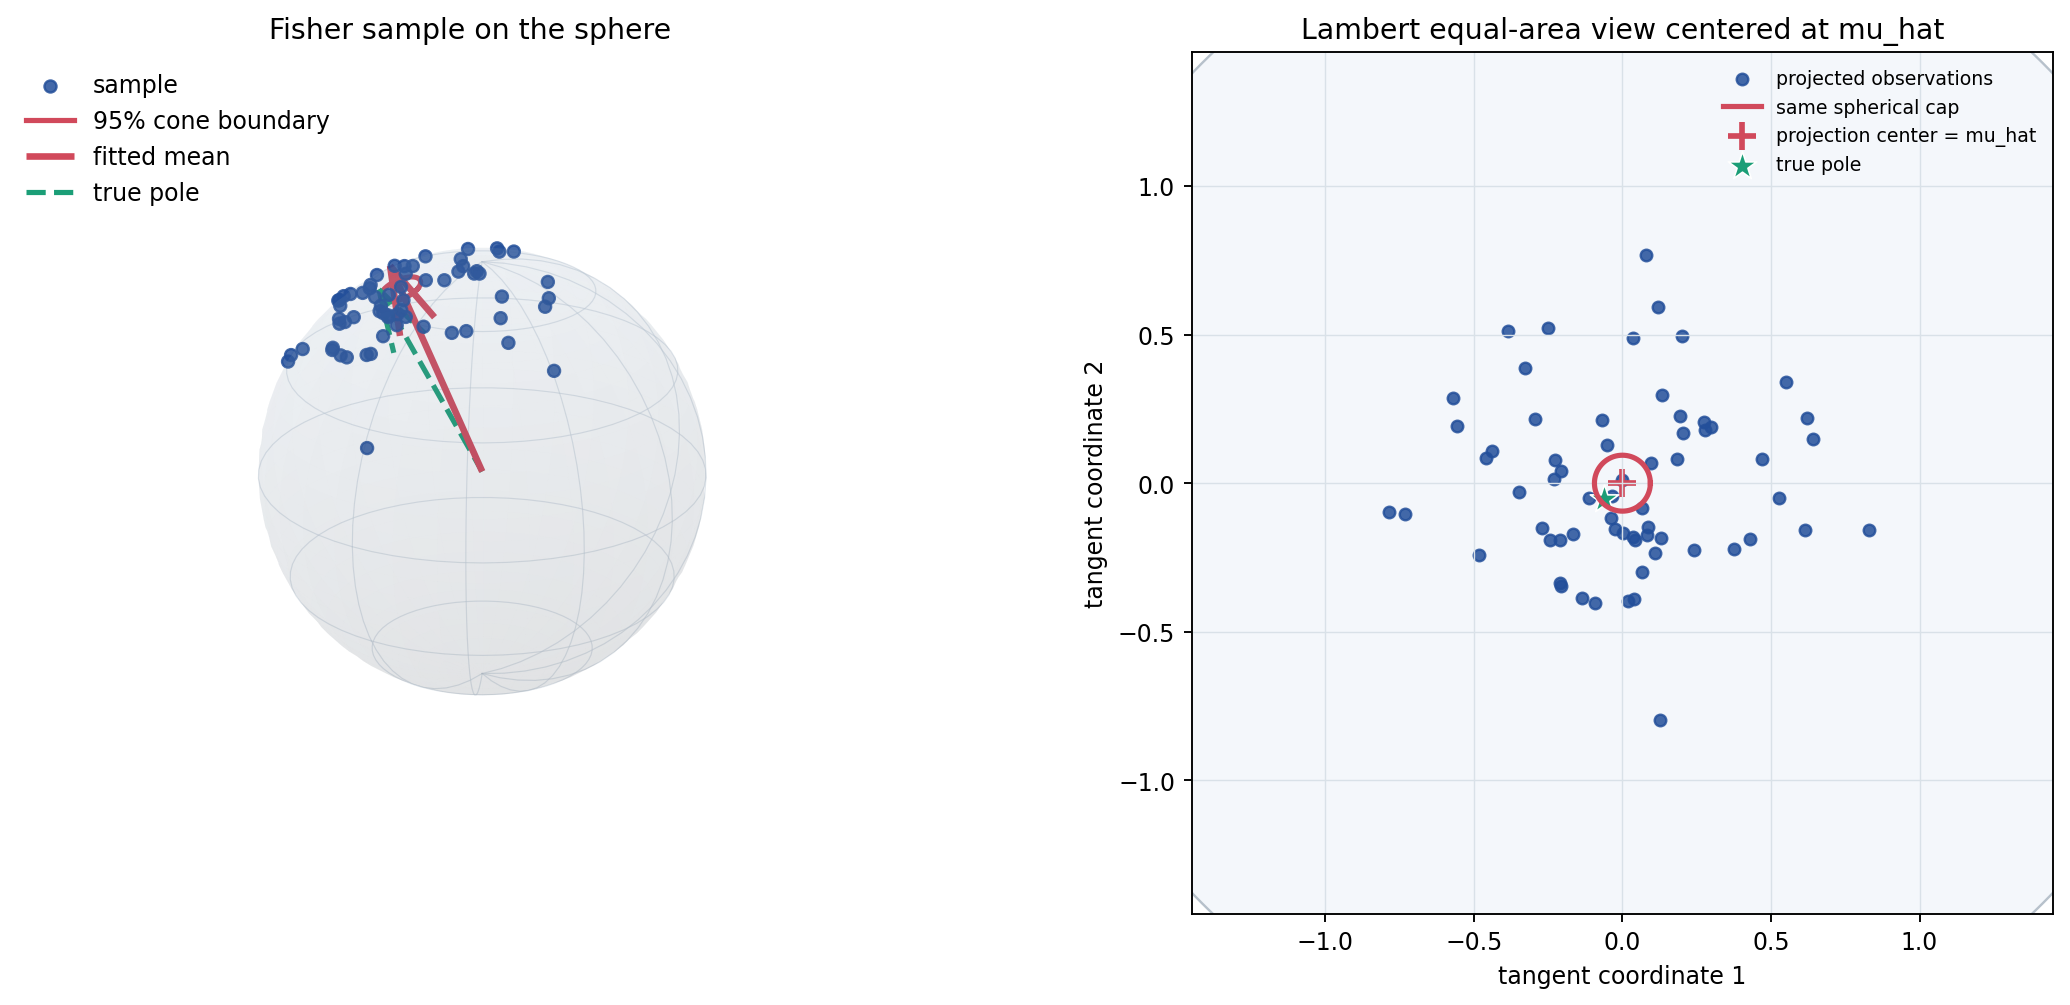

WindowsPath('artifacts/chapter-10/eda/spherical-eda-confidence-cone.png')

In [4]:
def draw_unit_sphere(ax, alpha=0.08):
    u = np.linspace(0.0, 2.0 * np.pi, 64)
    v = np.linspace(0.0, np.pi, 33)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    ax.plot_surface(xs, ys, zs, color="#9fbad6", alpha=alpha, linewidth=0)
    for latitude in np.radians([-60, -30, 0, 30, 60]):
        circle = np.column_stack([
            np.cos(latitude) * np.cos(u),
            np.cos(latitude) * np.sin(u),
            np.full_like(u, np.sin(latitude)),
        ])
        ax.plot(circle[:, 0], circle[:, 1], circle[:, 2], color="#c8d2dc", lw=0.5, alpha=0.55)
    for longitude in np.radians(np.arange(0, 180, 30)):
        meridian = np.column_stack([
            np.sin(v) * np.cos(longitude),
            np.sin(v) * np.sin(longitude),
            np.cos(v),
        ])
        ax.plot(meridian[:, 0], meridian[:, 1], meridian[:, 2], color="#c8d2dc", lw=0.5, alpha=0.55)


fig = plt.figure(figsize=(13.5, 5.8), constrained_layout=True)
ax3d = fig.add_subplot(1, 2, 1, projection="3d")
draw_unit_sphere(ax3d)
ax3d.scatter(fish_sample[:, 0], fish_sample[:, 1], fish_sample[:, 2], s=26, color="#234f9a", alpha=0.85, label="sample")
ax3d.plot(cone_boundary[:, 0], cone_boundary[:, 1], cone_boundary[:, 2], color="#d1495b", lw=2.2, label="95% cone boundary")
ax3d.quiver(0, 0, 0, mu_hat[0], mu_hat[1], mu_hat[2], length=1.12, color="#d1495b", linewidth=2.8, label="fitted mean")
ax3d.quiver(0, 0, 0, true_mu[0], true_mu[1], true_mu[2], length=1.04, color="#1b9e77", linewidth=2.2, linestyle="dashed", label="true pole")
ax3d.set_title("Fisher sample on the sphere")
ax3d.set_box_aspect([1, 1, 1])
ax3d.set_axis_off()
ax3d.view_init(elev=23, azim=34)
ax3d.legend(loc="upper left", bbox_to_anchor=(-0.04, 1.0), frameon=False)

ax2 = fig.add_subplot(1, 2, 2)
proj_sample = lambert_projection(fish_sample, mu_hat)
proj_boundary = lambert_projection(cone_boundary, mu_hat)
proj_true = lambert_projection(true_mu[None, :], mu_hat)[0]
unit_circle = np.column_stack([np.cos(np.linspace(0, 2 * np.pi, 361)), np.sin(np.linspace(0, 2 * np.pi, 361))]) * 2.0
ax2.fill(unit_circle[:, 0], unit_circle[:, 1], color="#f4f7fb", zorder=0)
ax2.plot(unit_circle[:, 0], unit_circle[:, 1], color="#b7c1cb", lw=1.0)
ax2.scatter(proj_sample[:, 0], proj_sample[:, 1], s=24, color="#234f9a", alpha=0.85, label="projected observations")
ax2.plot(proj_boundary[:, 0], proj_boundary[:, 1], color="#d1495b", lw=2.2, label="same spherical cap")
ax2.scatter([0], [0], marker="+", s=145, color="#d1495b", linewidth=2.4, label="projection center = mu_hat")
ax2.scatter([proj_true[0]], [proj_true[1]], marker="*", s=160, color="#1b9e77", edgecolor="white", linewidth=0.7, label="true pole")
ax2.set_title("Lambert equal-area view centered at mu_hat")
ax2.set_aspect("equal")
ax2.set_xlim(-1.45, 1.45)
ax2.set_ylim(-1.45, 1.45)
ax2.set_xlabel("tangent coordinate 1")
ax2.set_ylabel("tangent coordinate 2")
ax2.grid(color="#d9e1e8", lw=0.6)
ax2.legend(loc="upper right", frameon=False, fontsize=8)

eda_path = save_matplotlib(fig, TOPIC, "eda", "spherical-eda-confidence-cone.png", dpi=170)
plt.close(fig)
display_artifact(eda_path, width=980)
eda_path.relative_to(BOOK_ROOT)

## Fisher Concentration MLE And Cap Probability

For the Fisher model on `S^2`, the MLE of concentration solves

`A_3(kappa_hat) = Rbar`, where `A_3(kappa) = coth(kappa) - 1/kappa`.

This equation is the computational heart of concentration estimation. Large `Rbar` means the observations point in nearly the same direction, so the fitted `kappa` must be large. The confidence cone then uses the tangent-plane approximation `2 n kappa_hat (1 - mu_hat dot mu)`, which gives a cap threshold after solving for the chi-square quantile.

The cap probability plot distinguishes geometry from model fit. A uniform cap of semi-angle `alpha` has probability `(1 - cos(alpha)) / 2`; a Fisher cap around its pole can contain much more mass at the same angular radius.

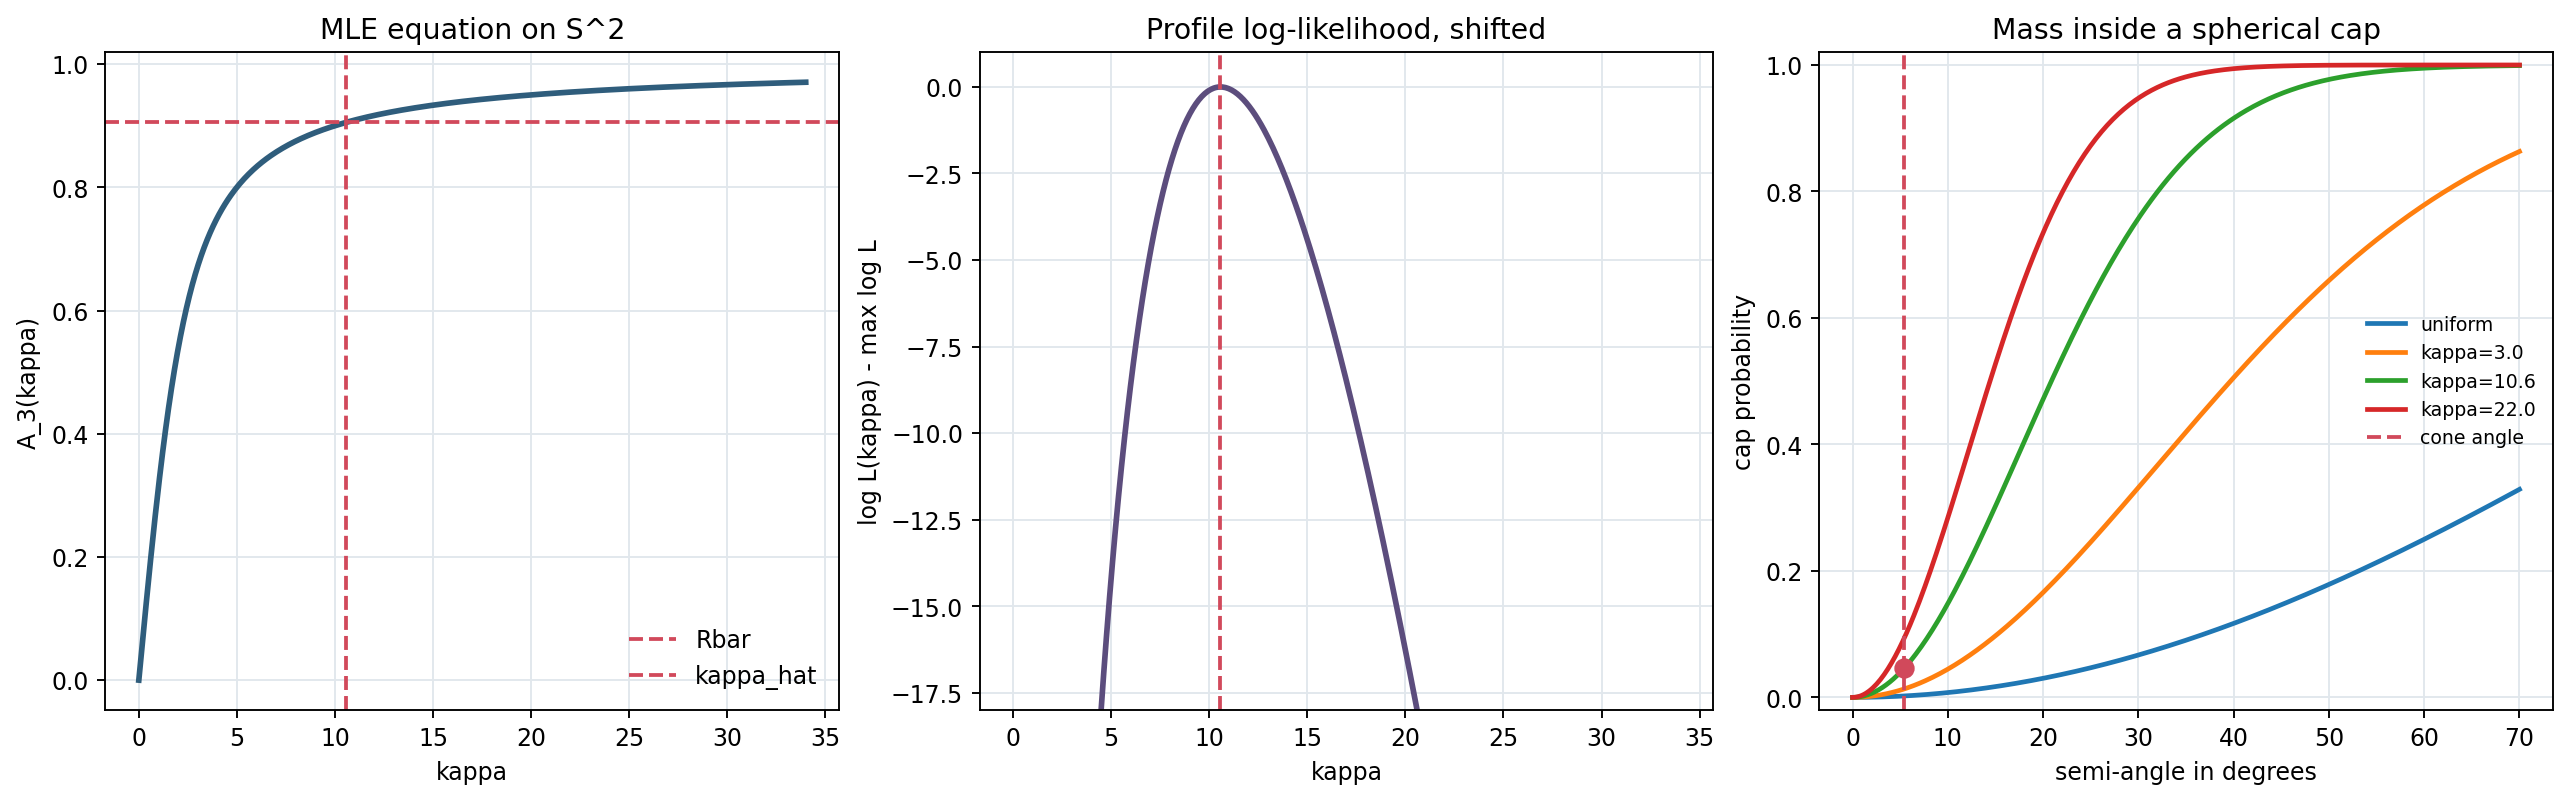

{'Rbar': 0.9054242377465048,
 'kappa_hat': 10.573533454351228,
 'A3_at_kappa_hat': 0.9054242377465047,
 'mle_equation_residual': 1.1102230246251565e-16,
 'cone_cosine_threshold': 0.9955730676999921,
 'cone_angle_degrees': 5.393235899461197,
 'fitted_vmf_mass_inside_cone': 0.04572970236069547,
 'uniform_mass_inside_same_cap': 0.002213466150003951}

In [5]:
k_grid = np.linspace(0.0, max(34.0, 1.55 * kappa_hat), 450)
a_grid = A3(k_grid)
profile = n_main * (k_grid * rbar + log_kappa_over_sinh(k_grid))
profile -= np.max(profile)
angles = np.linspace(0.0, np.radians(70.0), 360)
cap_kappas = [0.0, 3.0, float(kappa_hat), 22.0]

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.6), constrained_layout=True)

axes[0].plot(k_grid, a_grid, color="#2f5d7c", lw=2.4)
axes[0].axhline(rbar, color="#d1495b", lw=1.6, ls="--", label="Rbar")
axes[0].axvline(kappa_hat, color="#d1495b", lw=1.6, ls="--", label="kappa_hat")
axes[0].set_title("MLE equation on S^2")
axes[0].set_xlabel("kappa")
axes[0].set_ylabel("A_3(kappa)")
axes[0].legend(frameon=False)
axes[0].grid(color="#e1e7ec")

axes[1].plot(k_grid, profile, color="#5c4d7d", lw=2.4)
axes[1].axvline(kappa_hat, color="#d1495b", lw=1.6, ls="--")
axes[1].set_title("Profile log-likelihood, shifted")
axes[1].set_xlabel("kappa")
axes[1].set_ylabel("log L(kappa) - max log L")
axes[1].set_ylim(-18, 1.0)
axes[1].grid(color="#e1e7ec")

for k in cap_kappas:
    probabilities = [vmf_cap_probability(k, angle) for angle in angles]
    label = "uniform" if k == 0 else f"kappa={k:.1f}"
    axes[2].plot(np.degrees(angles), probabilities, lw=2.0, label=label)
axes[2].axvline(math.degrees(cone_angle), color="#d1495b", lw=1.6, ls="--", label="cone angle")
axes[2].scatter([math.degrees(cone_angle)], [cap_mass_fitted], s=58, color="#d1495b", zorder=3)
axes[2].set_title("Mass inside a spherical cap")
axes[2].set_xlabel("semi-angle in degrees")
axes[2].set_ylabel("cap probability")
axes[2].set_ylim(-0.02, 1.02)
axes[2].legend(frameon=False, fontsize=8)
axes[2].grid(color="#e1e7ec")

mle_path = save_matplotlib(fig, TOPIC, "inference", "fisher-kappa-mle-cap-probability.png", dpi=170)
plt.close(fig)
display_artifact(mle_path, width=980)

mle_checks = {
    "Rbar": rbar,
    "kappa_hat": kappa_hat,
    "A3_at_kappa_hat": A3(kappa_hat),
    "mle_equation_residual": mle_residual,
    "cone_cosine_threshold": cone_cos,
    "cone_angle_degrees": math.degrees(cone_angle),
    "fitted_vmf_mass_inside_cone": cap_mass_fitted,
    "uniform_mass_inside_same_cap": cap_mass_uniform,
}
mle_checks

## Uniformity Tests: Mean Shift Versus Axial Structure

Uniformity on a sphere is not one failure mode. A one-sided Fisher cluster has a nonzero vector resultant, so the Rayleigh statistic is natural. A bipolar or girdle pattern may have a small mean resultant but a non-uniform scatter spectrum, so Bingham's statistic is a better diagnostic.

The simulation below is a reference check, not a table lookup. Under uniformity, `3 n Rbar^2` is compared with a `chi^2_3` curve, while the Bingham scatter statistic is compared with a `chi^2_5` curve for `S^2`. The alternatives are deliberately different so the learner can see why both statistics are useful.

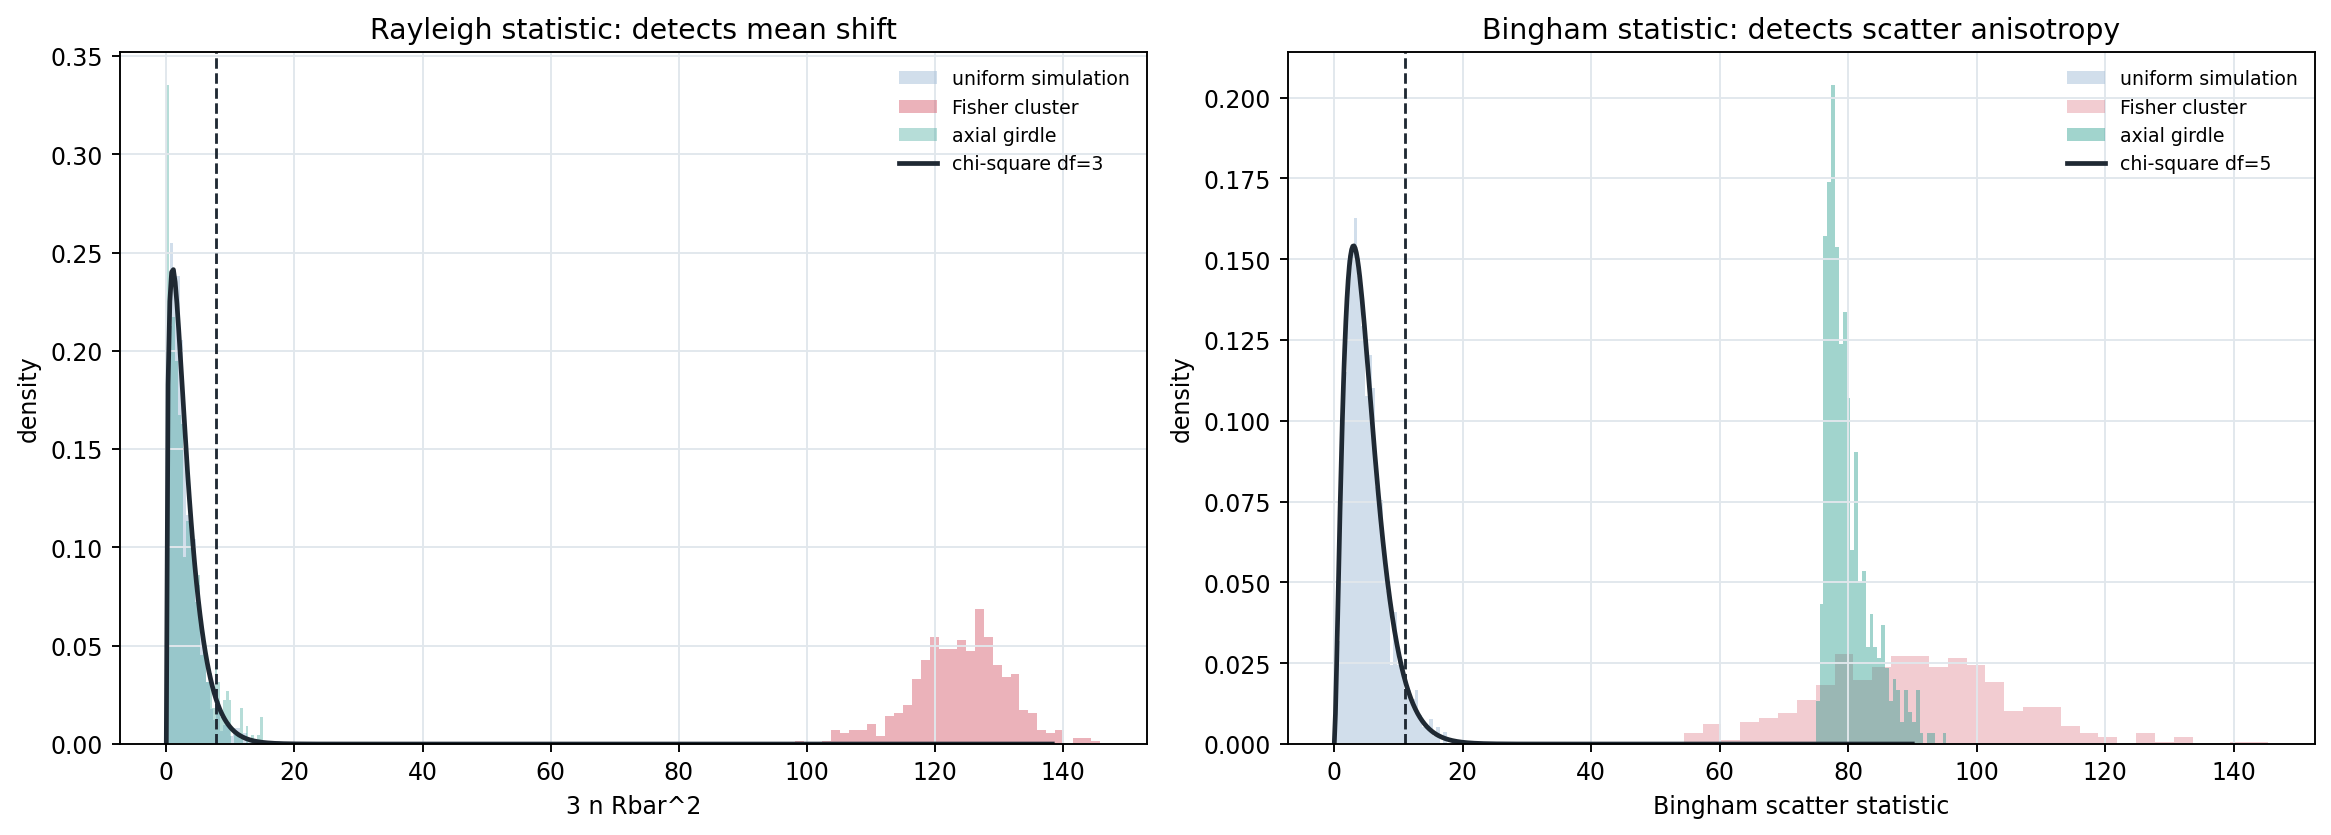

{'rayleigh_null_mean': 2.898253299906569,
 'rayleigh_chi2_df': 3,
 'rayleigh_null_q95': 7.48605553512649,
 'rayleigh_chi2_q95': 7.814727903251179,
 'rayleigh_vmf_mean': 123.95620301370128,
 'rayleigh_girdle_mean': 3.096065900357444,
 'bingham_null_mean': 5.025111789386191,
 'bingham_chi2_df': 5,
 'bingham_null_q95': 11.349625210842424,
 'bingham_chi2_q95': 11.070497693516351,
 'bingham_vmf_mean': 90.03472200584153,
 'bingham_girdle_mean': 80.02240903239523}

In [6]:
n_sim = 1400
n_alt = 500
uniform_sims = random_unit_sphere(n_sim * n_main, rng).reshape(n_sim, n_main, 3)
vmf_sims = np.stack([sample_vmf(true_mu, 5.0, n_main, rng) for _ in range(n_alt)])
girdle_axis = normalize(np.array([0.18, 0.82, 0.55]))
girdle_sims = np.stack([sample_girdle(girdle_axis, 0.09, n_main, rng) for _ in range(n_alt)])

rayleigh_null = rayleigh_stat_batch(uniform_sims)
rayleigh_vmf = rayleigh_stat_batch(vmf_sims)
rayleigh_girdle = rayleigh_stat_batch(girdle_sims)
bingham_null = bingham_stat_batch(uniform_sims)
bingham_vmf = bingham_stat_batch(vmf_sims)
bingham_girdle = bingham_stat_batch(girdle_sims)

x_ray = np.linspace(0.0, max(np.quantile(rayleigh_vmf, 0.98), stats.chi2.ppf(0.995, 3)), 500)
x_bing = np.linspace(0.0, max(np.quantile(bingham_girdle, 0.98), stats.chi2.ppf(0.995, 5)), 500)

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.8), constrained_layout=True)
axes[0].hist(rayleigh_null, bins=34, density=True, alpha=0.48, color="#9fbad6", label="uniform simulation")
axes[0].hist(rayleigh_vmf, bins=34, density=True, alpha=0.42, color="#d1495b", label="Fisher cluster")
axes[0].hist(rayleigh_girdle, bins=34, density=True, alpha=0.34, color="#2a9d8f", label="axial girdle")
axes[0].plot(x_ray, stats.chi2.pdf(x_ray, 3), color="#1f2933", lw=2.0, label="chi-square df=3")
axes[0].axvline(stats.chi2.ppf(0.95, 3), color="#1f2933", ls="--", lw=1.2)
axes[0].set_title("Rayleigh statistic: detects mean shift")
axes[0].set_xlabel("3 n Rbar^2")
axes[0].set_ylabel("density")
axes[0].legend(frameon=False, fontsize=8)
axes[0].grid(color="#e1e7ec")

axes[1].hist(bingham_null, bins=34, density=True, alpha=0.48, color="#9fbad6", label="uniform simulation")
axes[1].hist(bingham_vmf, bins=34, density=True, alpha=0.28, color="#d1495b", label="Fisher cluster")
axes[1].hist(bingham_girdle, bins=34, density=True, alpha=0.44, color="#2a9d8f", label="axial girdle")
axes[1].plot(x_bing, stats.chi2.pdf(x_bing, 5), color="#1f2933", lw=2.0, label="chi-square df=5")
axes[1].axvline(stats.chi2.ppf(0.95, 5), color="#1f2933", ls="--", lw=1.2)
axes[1].set_title("Bingham statistic: detects scatter anisotropy")
axes[1].set_xlabel("Bingham scatter statistic")
axes[1].set_ylabel("density")
axes[1].legend(frameon=False, fontsize=8)
axes[1].grid(color="#e1e7ec")

uniformity_path = save_matplotlib(fig, TOPIC, "tests", "uniformity-reference-behavior.png", dpi=170)
plt.close(fig)
display_artifact(uniformity_path, width=980)

uniformity_checks = {
    "rayleigh_null_mean": float(rayleigh_null.mean()),
    "rayleigh_chi2_df": 3,
    "rayleigh_null_q95": float(np.quantile(rayleigh_null, 0.95)),
    "rayleigh_chi2_q95": float(stats.chi2.ppf(0.95, 3)),
    "rayleigh_vmf_mean": float(rayleigh_vmf.mean()),
    "rayleigh_girdle_mean": float(rayleigh_girdle.mean()),
    "bingham_null_mean": float(bingham_null.mean()),
    "bingham_chi2_df": 5,
    "bingham_null_q95": float(np.quantile(bingham_null, 0.95)),
    "bingham_chi2_q95": float(stats.chi2.ppf(0.95, 5)),
    "bingham_vmf_mean": float(bingham_vmf.mean()),
    "bingham_girdle_mean": float(bingham_girdle.mean()),
}
uniformity_checks

## Axial Watson And Bingham Diagnostics

Axial observations represent lines through the origin, so `x` and `-x` are the same observation. A vector mean can be misleading because arbitrary sign choices can cancel it or create it. The scatter matrix `T = n^{-1} sum x_i x_i^T` is the right first diagnostic because it is unchanged by any sign flip.

The eigenvalues of `T` give a compact visual grammar:

- one large eigenvalue and two small nearly equal eigenvalues: bipolar Watson-like structure;
- two large nearly equal eigenvalues and one small eigenvalue: girdle Watson-like structure;
- three separated eigenvalues: a Bingham-like anisotropic axial pattern.

Inspection target: the sign-flip residual should be numerical zero, and the eigenvalue bars should reveal which alternative is being displayed.

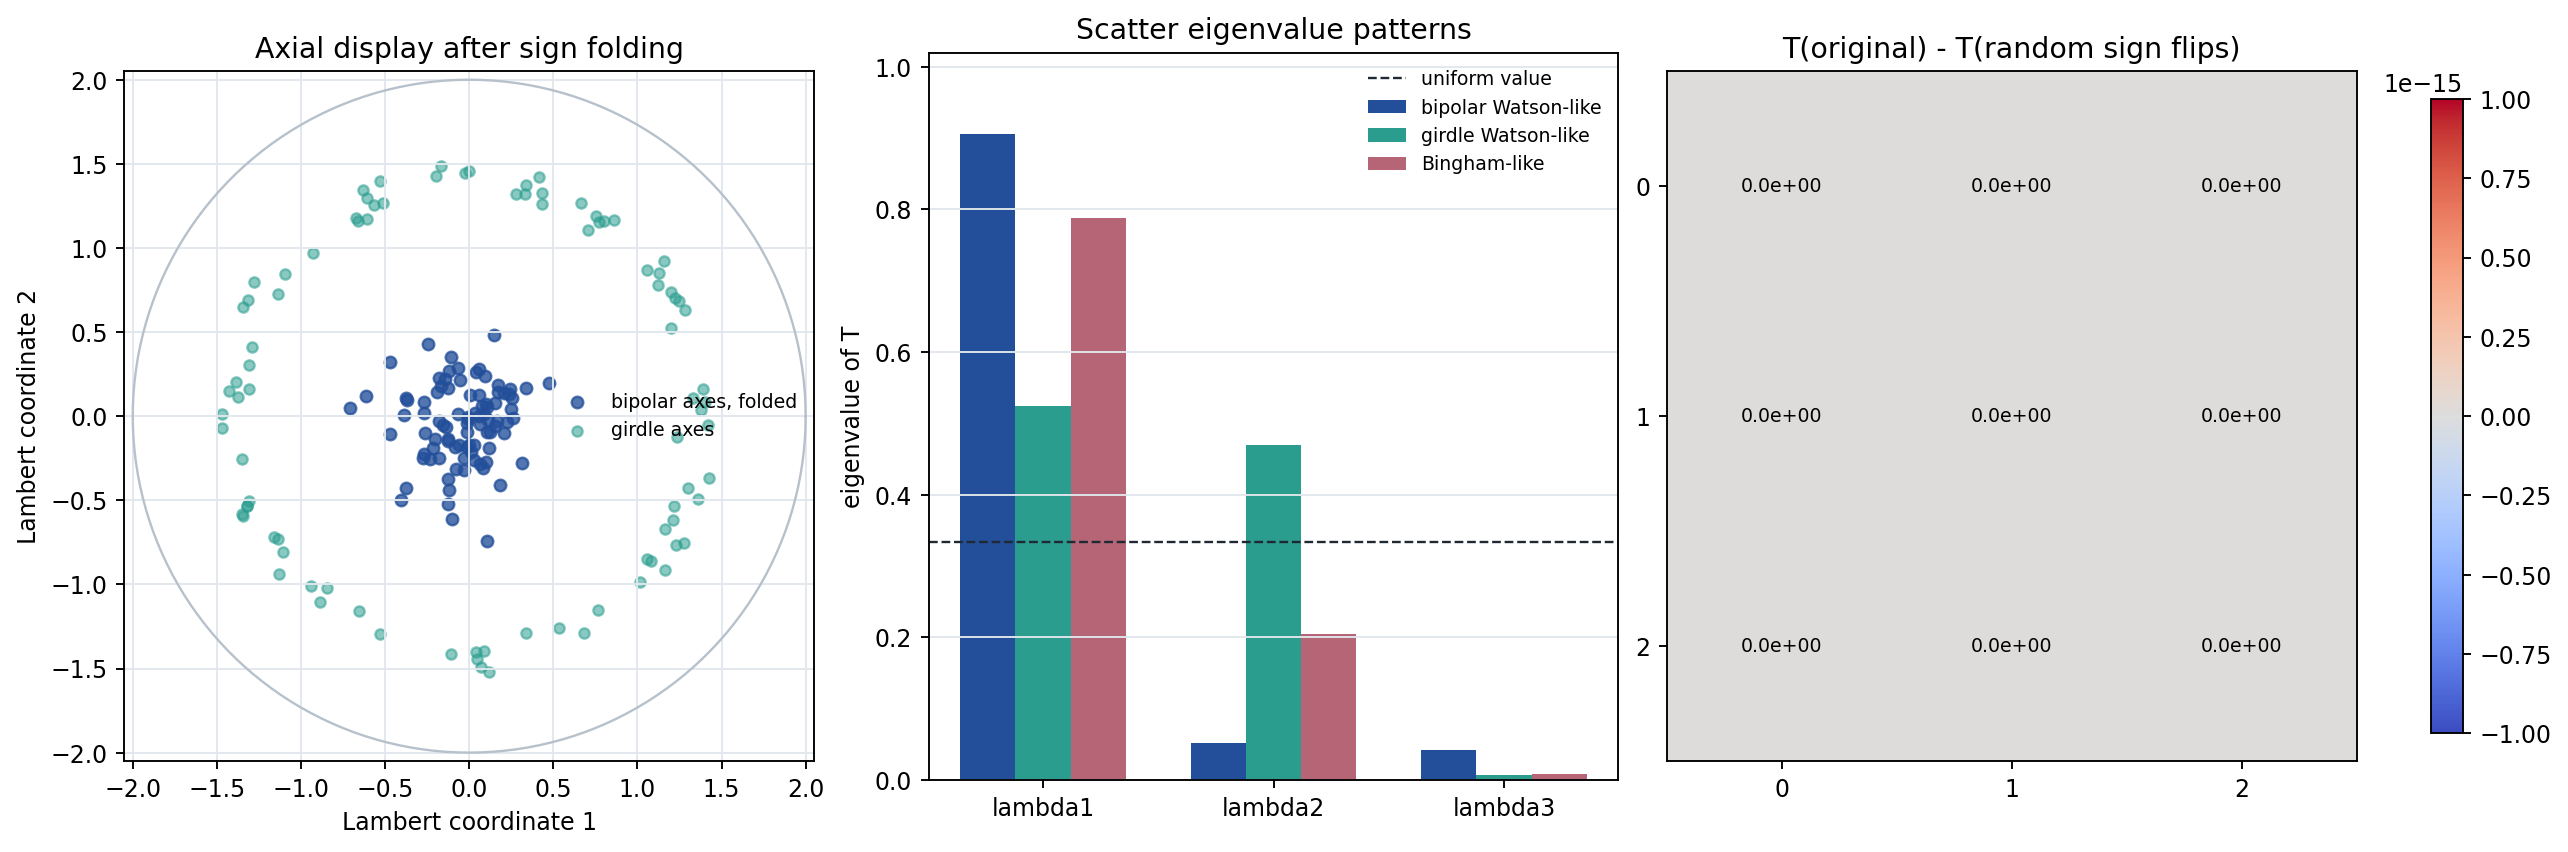

{'sign_symmetry_error_frobenius': 0.0,
 'diagnostics': {'bipolar Watson-like': {'eigenvalues_descending': [0.90649863185456,
    0.05183081363383744,
    0.04167055451160239],
   'trace': 0.9999999999999999,
   'rayleigh_statistic': 0.384053242636863,
   'bingham_statistic': 332.6597805888713},
  'girdle Watson-like': {'eigenvalues_descending': [0.5243768371090394,
    0.4693385609077504,
    0.006284601983210169],
   'trace': 0.9999999999999999,
   'rayleigh_statistic': 1.9700775331631242,
   'bingham_statistic': 109.32024258462965},
  'Bingham-like': {'eigenvalues_descending': [0.787820142189622,
    0.20397061700254968,
    0.008209240807828035],
   'trace': 0.9999999999999998,
   'rayleigh_statistic': 2.374026008806869,
   'bingham_statistic': 222.07408695543472}}}

In [7]:
axis_mu = normalize(np.array([0.18, 0.82, 0.55]))
n_axial = 90
bipolar_axes = rng.choice([-1.0, 1.0], size=n_axial)[:, None] * sample_vmf(axis_mu, 22.0, n_axial, rng)
girdle_axes = sample_girdle(axis_mu, 0.08, n_axial, rng)
elliptic_axes = sample_elliptic_axial(axis_mu, n_axial, rng)

flip_signs = rng.choice([-1.0, 1.0], size=n_axial)[:, None]
scatter_original = scatter_matrix(bipolar_axes)
scatter_flipped = scatter_matrix(flip_signs * bipolar_axes)
sign_symmetry_error = float(np.linalg.norm(scatter_original - scatter_flipped, ord="fro"))

axial_sets = {
    "bipolar Watson-like": bipolar_axes,
    "girdle Watson-like": girdle_axes,
    "Bingham-like": elliptic_axes,
}
axial_diagnostics = {}
for name, points in axial_sets.items():
    eigvals, eigvecs = scatter_eigensystem(points)
    axial_diagnostics[name] = {
        "eigenvalues_descending": eigvals.tolist(),
        "trace": float(eigvals.sum()),
        "rayleigh_statistic": rayleigh_stat(points),
        "bingham_statistic": bingham_stat(points),
    }

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.9), constrained_layout=True)

oriented_bipolar = orient_axes_to_hemisphere(bipolar_axes, axis_mu)
proj_bipolar = lambert_projection(oriented_bipolar, axis_mu)
proj_girdle = lambert_projection(girdle_axes, axis_mu)
axes[0].scatter(proj_bipolar[:, 0], proj_bipolar[:, 1], s=24, color="#234f9a", alpha=0.78, label="bipolar axes, folded")
axes[0].scatter(proj_girdle[:, 0], proj_girdle[:, 1], s=19, color="#2a9d8f", alpha=0.55, label="girdle axes")
cap = np.column_stack([np.cos(np.linspace(0, 2*np.pi, 361)), np.sin(np.linspace(0, 2*np.pi, 361))]) * 2.0
axes[0].plot(cap[:, 0], cap[:, 1], color="#b7c1cb", lw=1.0)
axes[0].set_aspect("equal")
axes[0].set_xlim(-2.05, 2.05)
axes[0].set_ylim(-2.05, 2.05)
axes[0].set_title("Axial display after sign folding")
axes[0].set_xlabel("Lambert coordinate 1")
axes[0].set_ylabel("Lambert coordinate 2")
axes[0].legend(frameon=False, fontsize=8)
axes[0].grid(color="#e1e7ec")

x = np.arange(3)
width = 0.24
colors = ["#234f9a", "#2a9d8f", "#b56576"]
for offset, (color, (name, points)) in enumerate(zip(colors, axial_sets.items())):
    eigvals = np.array(axial_diagnostics[name]["eigenvalues_descending"])
    axes[1].bar(x + (offset - 1) * width, eigvals, width=width, color=color, label=name)
axes[1].axhline(1/3, color="#1f2933", lw=1.0, ls="--", label="uniform value")
axes[1].set_xticks(x)
axes[1].set_xticklabels(["lambda1", "lambda2", "lambda3"])
axes[1].set_ylim(0.0, 1.02)
axes[1].set_title("Scatter eigenvalue patterns")
axes[1].set_ylabel("eigenvalue of T")
axes[1].legend(frameon=False, fontsize=8)
axes[1].grid(axis="y", color="#e1e7ec")

image = axes[2].imshow(scatter_original - scatter_flipped, cmap="coolwarm", vmin=-1e-15, vmax=1e-15)
axes[2].set_xticks([0, 1, 2])
axes[2].set_yticks([0, 1, 2])
axes[2].set_title("T(original) - T(random sign flips)")
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, f"{scatter_original[i, j] - scatter_flipped[i, j]:.1e}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)

axial_path = save_matplotlib(fig, TOPIC, "axial", "watson-bingham-sign-symmetry-diagnostics.png", dpi=170)
plt.close(fig)
display_artifact(axial_path, width=980)

axial_checks = {
    "sign_symmetry_error_frobenius": sign_symmetry_error,
    "diagnostics": axial_diagnostics,
}
axial_checks

## Interactive Spherical Inference Dashboard

The static artifacts are the audit trail; the Plotly artifact is the inspection surface. Rotate the sphere and look for three alignments: the blue Fisher cluster around the fitted pole, the red cone boundary on the sphere, and the green axial girdle around its normal axis.

This view uses Plotly because the cap/cone relationship is easiest to inspect by rotation. The same numeric objects are checked again at the end of the notebook.

In [8]:
sphere_u = np.linspace(0.0, 2.0 * np.pi, 60)
sphere_v = np.linspace(0.0, np.pi, 31)
sphere_x = np.outer(np.cos(sphere_u), np.sin(sphere_v))
sphere_y = np.outer(np.sin(sphere_u), np.sin(sphere_v))
sphere_z = np.outer(np.ones_like(sphere_u), np.cos(sphere_v))

girdle_for_html = sample_girdle(axis_mu, 0.07, 120, rng)
axis_line = np.vstack([-axis_mu, axis_mu])
mean_line = np.vstack([np.zeros(3), mu_hat])
true_line = np.vstack([np.zeros(3), true_mu])

fig3d = go.Figure()
fig3d.add_trace(go.Surface(
    x=sphere_x,
    y=sphere_y,
    z=sphere_z,
    opacity=0.16,
    showscale=False,
    colorscale=[[0, "#d9e6f2"], [1, "#d9e6f2"]],
    hoverinfo="skip",
    name="unit sphere",
))
fig3d.add_trace(go.Scatter3d(
    x=fish_sample[:, 0], y=fish_sample[:, 1], z=fish_sample[:, 2],
    mode="markers",
    marker=dict(size=4, color="#234f9a", opacity=0.82),
    name="Fisher sample",
))
fig3d.add_trace(go.Scatter3d(
    x=cone_boundary[:, 0], y=cone_boundary[:, 1], z=cone_boundary[:, 2],
    mode="lines",
    line=dict(color="#d1495b", width=6),
    name="95% confidence cone boundary",
))
fig3d.add_trace(go.Scatter3d(
    x=mean_line[:, 0], y=mean_line[:, 1], z=mean_line[:, 2],
    mode="lines",
    line=dict(color="#d1495b", width=8),
    name="fitted mean direction",
))
fig3d.add_trace(go.Scatter3d(
    x=true_line[:, 0], y=true_line[:, 1], z=true_line[:, 2],
    mode="lines",
    line=dict(color="#1b9e77", width=7, dash="dash"),
    name="true pole",
))
fig3d.add_trace(go.Scatter3d(
    x=girdle_for_html[:, 0], y=girdle_for_html[:, 1], z=girdle_for_html[:, 2],
    mode="markers",
    marker=dict(size=3, color="#2a9d8f", opacity=0.48),
    name="axial girdle sample",
))
fig3d.add_trace(go.Scatter3d(
    x=axis_line[:, 0], y=axis_line[:, 1], z=axis_line[:, 2],
    mode="lines",
    line=dict(color="#2a9d8f", width=7),
    name="girdle normal axis",
))
fig3d.update_layout(
    title="Chapter 10 spherical inference: mean cone and axial diagnostics",
    scene=dict(
        xaxis=dict(range=[-1.05, 1.05], showbackground=False, zeroline=False),
        yaxis=dict(range=[-1.05, 1.05], showbackground=False, zeroline=False),
        zaxis=dict(range=[-1.05, 1.05], showbackground=False, zeroline=False),
        aspectmode="cube",
    ),
    legend=dict(x=0.02, y=0.98),
    margin=dict(l=0, r=0, t=48, b=0),
)

interactive_path = save_plotly_html(
    fig3d,
    TOPIC,
    "interactive",
    "spherical-inference-dashboard.html",
    include_plotlyjs=True,
)
display_artifact(interactive_path, width="100%", height=620)
interactive_path.relative_to(BOOK_ROOT)

WindowsPath('artifacts/chapter-10/interactive/spherical-inference-dashboard.html')

## Applied Lab: How Stable Is The Confidence Cone Approximation?

The confidence cone is an asymptotic object. It is most reliable when the sample is not tiny and the concentration is not weak. The lab below repeats the fitting and cone test for several `(n, kappa)` settings. The target is not exact Monte Carlo coverage; the target is to connect the cone angle, the MLE equation residual, and the event that the true pole lies in the fitted cone.

Read the table as a calibration device. Larger `n * kappa` should lead to narrower cones, while the empirical containment rate should remain near the nominal 95% level in these concentrated cases.

In [9]:
def cone_coverage_lab(n, kappa, reps, rng):
    contains = []
    angles = []
    residuals = []
    rbars = []
    for _ in range(reps):
        sample = sample_vmf(true_mu, kappa, n, rng)
        mu_fit, rbar_fit, _ = mean_direction(sample)
        k_fit = solve_kappa_from_rbar(min(rbar_fit, 0.999999999))
        cos_cut = confidence_cone_cosine(n, k_fit, level=0.95)
        contains.append(float(np.dot(mu_fit, true_mu)) >= cos_cut)
        angles.append(math.degrees(math.acos(cos_cut)))
        residuals.append(abs(A3(k_fit) - rbar_fit))
        rbars.append(rbar_fit)
    return {
        "n": n,
        "kappa": kappa,
        "reps": reps,
        "empirical_containment_rate": float(np.mean(contains)),
        "mean_cone_angle_degrees": float(np.mean(angles)),
        "median_Rbar": float(np.median(rbars)),
        "max_mle_residual": float(np.max(residuals)),
    }


lab_rows = [
    cone_coverage_lab(48, 7.0, 260, rng),
    cone_coverage_lab(72, 11.0, 260, rng),
    cone_coverage_lab(120, 17.0, 260, rng),
]
lab_path = save_json({"source_span": source_span, "cone_coverage_lab": lab_rows}, TOPIC, "checks", "simulation-reference-checks.json")
display_artifact(lab_path)
lab_rows

[{'n': 48,
  'kappa': 7.0,
  'reps': 260,
  'empirical_containment_rate': 0.9346153846153846,
  'mean_cone_angle_degrees': 7.5494314553399535,
  'median_Rbar': 0.8605298340669829,
  'max_mle_residual': 9.992007221626409e-16},
 {'n': 72,
  'kappa': 11.0,
  'reps': 260,
  'empirical_containment_rate': 0.9346153846153846,
  'mean_cone_angle_degrees': 4.943994471065054,
  'median_Rbar': 0.9110180057989663,
  'max_mle_residual': 2.4424906541753444e-15},
 {'n': 120,
  'kappa': 17.0,
  'reps': 260,
  'empirical_containment_rate': 0.926923076923077,
  'mean_cone_angle_degrees': 3.080839120300235,
  'median_Rbar': 0.9425034972409281,
  'max_mle_residual': 2.220446049250313e-16}]

## Consolidated Sanity Checks

The final checks intentionally overlap the visuals. A visual artifact should have a nearby mathematical claim, and the notebook should save a machine-readable version of that claim.

Checks included:

- all simulated observations used in the chapter are unit vectors;
- the Fisher concentration MLE solves `A_3(kappa_hat) = Rbar`;
- the confidence cone has a valid cap threshold, the cap mass logic is ordered correctly, and the reference true pole is inside the fitted cone;
- Rayleigh's uniform null behavior is close to `chi^2_3`, and Fisher clustering moves the Rayleigh statistic upward;
- the Bingham scatter statistic responds strongly to axial girdles;
- axial scatter is invariant under arbitrary sign flips;
- all generated artifacts exist, are book-local, and have nonzero size.

In [10]:
all_chapter_points = np.vstack([
    fish_sample,
    bipolar_axes,
    girdle_axes,
    elliptic_axes,
    girdle_for_html,
])
unit_norm_error = float(np.max(np.abs(np.linalg.norm(all_chapter_points, axis=1) - 1.0)))

boolean_checks = {
    "unit_vectors_on_sphere": unit_norm_error < 1e-12,
    "mle_equation_residual_small": mle_residual < 1e-11,
    "confidence_cone_threshold_valid": -1.0 <= cone_cos <= 1.0 and 0.0 < cone_angle < (np.pi / 2.0),
    "reference_true_pole_inside_cone": bool(float(np.dot(true_mu, mu_hat)) >= cone_cos),
    "fisher_cap_exceeds_uniform_cap_same_angle": cap_mass_fitted > cap_mass_uniform,
    "rayleigh_uniform_mean_near_chi2_mean": abs(uniformity_checks["rayleigh_null_mean"] - 3.0) < 0.35,
    "rayleigh_detects_fisher_cluster": uniformity_checks["rayleigh_vmf_mean"] > uniformity_checks["rayleigh_null_q95"],
    "bingham_uniform_mean_near_chi2_mean": abs(uniformity_checks["bingham_null_mean"] - 5.0) < 0.85,
    "bingham_detects_axial_girdle": uniformity_checks["bingham_girdle_mean"] > uniformity_checks["bingham_null_q95"],
    "axial_sign_symmetry_preserved": sign_symmetry_error < 1e-12,
    "cone_lab_containment_reasonable": min(row["empirical_containment_rate"] for row in lab_rows) > 0.88,
}
assert all(boolean_checks.values()), boolean_checks

numeric_checks = {
    "source_span": source_span,
    "unit_norm_error": unit_norm_error,
    "eda": eda_summary,
    "fisher_mle_and_cap": mle_checks,
    "uniformity_reference": uniformity_checks,
    "axial_watson_bingham": axial_checks,
    "cone_coverage_lab": lab_rows,
    "boolean_checks": boolean_checks,
}
checks_path = save_json(numeric_checks, TOPIC, "checks", "numeric-checks.json")
display_artifact(checks_path)
numeric_checks

{'source_span': {'printed': '193-244', 'pdf': '209-259'},
 'unit_norm_error': 2.220446049250313e-16,
 'eda': {'n': 64,
  'true_kappa': 12.0,
  'Rbar': 0.9054242377465048,
  'kappa_hat': 10.573533454351228,
  'mle_equation_residual': 1.1102230246251565e-16,
  'cone_level': 0.95,
  'cone_angle_degrees': 5.393235899461197,
  'true_pole_angle_to_mu_hat_degrees': 4.790745253409691,
  'true_pole_inside_reference_cone': True,
  'fitted_vmf_mass_inside_cone': 0.04572970236069547,
  'uniform_mass_inside_same_cap': 0.002213466150003951},
 'fisher_mle_and_cap': {'Rbar': 0.9054242377465048,
  'kappa_hat': 10.573533454351228,
  'A3_at_kappa_hat': 0.9054242377465047,
  'mle_equation_residual': 1.1102230246251565e-16,
  'cone_cosine_threshold': 0.9955730676999921,
  'cone_angle_degrees': 5.393235899461197,
  'fitted_vmf_mass_inside_cone': 0.04572970236069547,
  'uniform_mass_inside_same_cap': 0.002213466150003951},
 'uniformity_reference': {'rayleigh_null_mean': 2.898253299906569,
  'rayleigh_chi2_df

In [11]:
artifact_paths = [
    eda_path,
    mle_path,
    uniformity_path,
    axial_path,
    interactive_path,
    lab_path,
    checks_path,
]
assert all(artifact_is_under(path, ARTIFACT_BASE) for path in artifact_paths), artifact_paths
artifact_records = assert_artifacts(artifact_paths, min_bytes=100)

final_sanity = {
    "source_span": source_span,
    "pdf_used_for": "orientation only: section order, terminology, and concept coverage",
    "artifacts": artifact_records,
    "core_boolean_checks": boolean_checks,
    "core_numeric_checks": {
        "unit_norm_error": unit_norm_error,
        "mle_equation_residual": mle_residual,
        "cone_angle_degrees": math.degrees(cone_angle),
        "rayleigh_null_mean": uniformity_checks["rayleigh_null_mean"],
        "bingham_null_mean": uniformity_checks["bingham_null_mean"],
        "axial_sign_symmetry_error_frobenius": sign_symmetry_error,
        "minimum_lab_containment": min(row["empirical_containment_rate"] for row in lab_rows),
    },
    "standalone_contract": "original prose, generated visuals, executable examples, and chapter-specific checks",
}
final_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
final_sanity["artifacts"] = assert_artifacts([*artifact_paths, final_path], min_bytes=100)
final_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
assert final_path.exists() and final_path.stat().st_size > 20
final_sanity

{'source_span': {'printed': '193-244', 'pdf': '209-259'},
 'pdf_used_for': 'orientation only: section order, terminology, and concept coverage',
 'artifacts': [{'path': 'artifacts/chapter-10/eda/spherical-eda-confidence-cone.png',
   'exists': True,
   'bytes': 228823},
  {'path': 'artifacts/chapter-10/inference/fisher-kappa-mle-cap-probability.png',
   'exists': True,
   'bytes': 162338},
  {'path': 'artifacts/chapter-10/tests/uniformity-reference-behavior.png',
   'exists': True,
   'bytes': 95733},
  {'path': 'artifacts/chapter-10/axial/watson-bingham-sign-symmetry-diagnostics.png',
   'exists': True,
   'bytes': 174898},
  {'path': 'artifacts/chapter-10/interactive/spherical-inference-dashboard.html',
   'exists': True,
   'bytes': 4952334},
  {'path': 'artifacts/chapter-10/checks/simulation-reference-checks.json',
   'exists': True,
   'bytes': 932},
  {'path': 'artifacts/chapter-10/checks/numeric-checks.json',
   'exists': True,
   'bytes': 4006},
  {'path': 'artifacts/chapter-10

## Takeaways

Spherical inference works when the statistic matches the sample space. The mean resultant is a vector diagnostic for one-sided clustering, not a universal measure of non-uniformity. The scatter matrix is the natural first object for axial data because it ignores the arbitrary sign of an axis. A confidence region for a mean direction is a spherical cap, and its probability is a cap probability, not a planar area.

The recurring workflow is compact: keep observations on the sphere, choose the statistic whose invariance matches the scientific question, draw the statistic on the sphere, and save a check that would fail if the data were flattened too early.